# 04 -- Varianty strategie (parameter sweep)

V notebooku 03 jsme testovali jednu konkretni kombinaci parametru
(z-score prah 1.5 / 1.0, 1-denni holding period), zvolenou "od oka".
Ted systematicky prozkoumame vic kombinaci -- ruzne prahy z-score i
delsi holding periody (drzet pozici vic nez 1 den).

**DULEZITE UPOZORNENI K METODOLOGII:** cim vic kombinaci parametru
vyzkousime, tim vetsi je sance, ze nejaka z nich bude vypadat dobre
cistou nahodou (tzv. multiple comparisons problem / data snooping).
Abychom se tomu vyhnuli:

1. Cely parameter sweep delame **jen na trenovaci casti dat** (prvnich
   70 %, stejne rozdeleni jako v notebooku 03)
2. Nejlepsi kombinaci pak overime **jen jednou** na testovaci casti --
   nesmime se vratit a zkouset dalsi kombinace, kdyby vysledek na testu
   nevysel dobre, to by bylo presne to spatne "p-hacking" chovani

## Import knihoven

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
np.random.seed(42)

In [11]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROCESSED_DIR / "merged_price_sentiment.csv", parse_dates=["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
print(f"Nacteno {len(df)} radku")
df.head()

Nacteno 2359 radku


,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,Volatility_5d,post_count,avg_sentiment,positive_count,negative_count,sentiment_zscore,post_count_zscore,Forward_Return
0,2020-01-02,72.333893,72.394101,71.091199,71.344069,135480400,AAPL,NaN,NaN,7.0,0.329305,3.0,0.0,NaN,NaN,-0.009722
1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800,AAPL,-0.009722,NaN,6.0,0.278295,2.0,0.0,NaN,NaN,0.007968
2,2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,AAPL,0.007968,NaN,5.0,-0.159124,1.0,2.0,NaN,NaN,-0.004703
3,2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000,AAPL,-0.004703,NaN,0.0,0.000000,0.0,0.0,NaN,NaN,0.016086
4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,AAPL,0.016086,NaN,4.0,-0.066181,1.0,1.0,-0.660838,-0.148047,0.021241


## Vicedenni forward returns

V notebooku 03 jsme meli jen 1-denni holding period (Close T -> Close T+1).
Ted pridame i 3 a 5-denni varianty, at muzeme otestovat, jestli sentiment
signal potrebuje vic casu se projevit v cene.

In [12]:
HOLDING_PERIODS = [1, 3, 5]

for h in HOLDING_PERIODS:
    df[f"Forward_Return_{h}d"] = df.groupby("Ticker")["Close"].shift(-h) / df["Close"] - 1

## Chronologicky train/test split

Stejne rozdeleni jako v notebooku 03 -- 70 % trenovaci, 30 % testovaci,
podle casu (ne nahodne), aby test skutecne simuloval "budoucnost", kterou
model behem ladeni parametru nevidel.

In [13]:
all_dates = pd.Series(sorted(df["Date"].unique()))
split_idx = int(len(all_dates) * 0.7)
split_date = all_dates.iloc[split_idx]

train_df = df[df["Date"] <= split_date].copy()
test_df = df[df["Date"] > split_date].copy()

print(f"Trenovaci obdobi: {all_dates.iloc[0].date()} az {split_date.date()} ({len(train_df)} radku)")
print(f"Testovaci obdobi: {split_date.date()} az {all_dates.iloc[-1].date()} ({len(test_df)} radku)")

Trenovaci obdobi: 2020-01-02 az 2020-10-14 (1603 radku)
Testovaci obdobi: 2020-10-14 az 2021-02-16 (756 radku)


## Parameter sweep na trenovacich datech

Pro kazdou kombinaci (sentiment prah, volume prah, holding period)
spocitame:
- pocet obchodu (aby se odfiltrovaly kombinace s prilis malo obchody --
  na tech je jakykoliv vysledek nespolehlivy)
- prumerny vynos na obchod
- Sharpe-like pomer (prumer / smerodatna odchylka vynosu na obchod)

Vyhybame se tady stavbe cele equity krivky (jako v notebooku 03) --
pri delsich holding periods by se pozice prekryvaly a slozilo by to
vypocet zbytecne. Misto toho hodnotime **distribuci vynosu jednotlivych
obchodu**, coz je pro srovnani parametru dostatecne a jednodussi.

In [14]:
TRANSACTION_COST = 0.001
MIN_TRADES = 20  # kombinace s min poctem obchodu ignorujeme, nejsou spolehlive

sentiment_thresholds = [1.0, 1.5, 2.0, 2.5]
volume_thresholds = [0.5, 1.0, 1.5]

results = []

for h in HOLDING_PERIODS:
    return_col = f"Forward_Return_{h}d"
    for s_thresh in sentiment_thresholds:
        for v_thresh in volume_thresholds:
            signal = (
                (train_df["sentiment_zscore"] > s_thresh)
                & (train_df["post_count_zscore"] > v_thresh)
            )
            trade_returns = train_df.loc[signal, return_col].dropna() - TRANSACTION_COST

            if len(trade_returns) < MIN_TRADES:
                continue

            mean_ret = trade_returns.mean()
            std_ret = trade_returns.std()
            sharpe_like = mean_ret / std_ret if std_ret > 0 else np.nan

            results.append({
                "holding_period": h,
                "sentiment_threshold": s_thresh,
                "volume_threshold": v_thresh,
                "n_trades": len(trade_returns),
                "mean_return": mean_ret,
                "sharpe_like": sharpe_like,
                "win_rate": (trade_returns > 0).mean(),
            })

sweep_results = pd.DataFrame(results).sort_values("sharpe_like", ascending=False)
print(f"Otestovano {len(sweep_results)} kombinaci (po odfiltrovani < {MIN_TRADES} obchodu)")
sweep_results.head(10)

Otestovano 15 kombinaci (po odfiltrovani < 20 obchodu)


,holding_period,sentiment_threshold,volume_threshold,n_trades,mean_return,sharpe_like,win_rate
3,1,1.5,0.5,27,0.011417,0.375879,0.740741
8,3,1.5,0.5,27,0.021920,0.285149,0.666667
9,3,1.5,1.0,21,0.020271,0.240800,0.666667
4,1,1.5,1.0,21,0.007058,0.231755,0.714286
7,3,1.0,1.5,28,0.023741,0.230860,0.642857
12,5,1.0,1.5,28,0.030862,0.225868,0.607143
5,3,1.0,0.5,57,0.013984,0.152519,0.561404
6,3,1.0,1.0,42,0.012170,0.118481,0.571429
14,5,1.5,1.0,21,0.014436,0.113151,0.571429
2,1,1.0,1.5,28,0.006785,0.112602,0.642857


### Vizualizace -- heatmapa pro 1-denni holding period

Podivame se, jak Sharpe-like pomer zavisi na kombinaci prahu (pro
prehlednost jen pro 1-denni holding, ostatni periody jsou v tabulce
vyse).

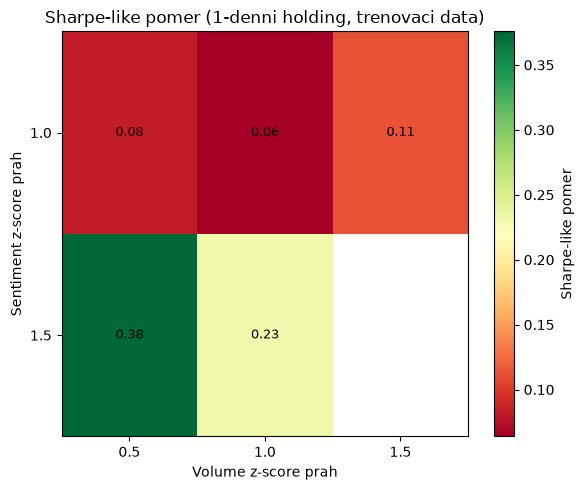

In [15]:
pivot = (
    sweep_results[sweep_results["holding_period"] == 1]
    .pivot(index="sentiment_threshold", columns="volume_threshold", values="sharpe_like")
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Volume z-score prah")
ax.set_ylabel("Sentiment z-score prah")
ax.set_title("Sharpe-like pomer (1-denni holding, trenovaci data)")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

plt.colorbar(im, label="Sharpe-like pomer")
plt.tight_layout()
plt.show()

## Vyber nejlepsi kombinace (jen podle trenovacich dat!)

Vybirame kombinaci s nejvyssim Sharpe-like pomerem **mezi kombinacemi
s dostatecnym poctem obchodu** -- extremni pomery z 20-30 obchodu jsou
casto jen sum, ne skutecny signal.

In [16]:
best_config = sweep_results.iloc[0]
print("Nejlepsi kombinace na trenovacich datech:")
print(best_config)

Nejlepsi kombinace na trenovacich datech:
holding_period          1.000000
sentiment_threshold     1.500000
volume_threshold        0.500000
n_trades               27.000000
mean_return             0.011417
sharpe_like             0.375879
win_rate                0.740741
Name: 3, dtype: float64


## Overeni na testovacich datech -- JEN JEDNOU

Tohle je jediny pohled, ktery na testovaci data vrhame. At uz vyjde
vysledek dobre nebo spatne, tohle je financi odpoved -- nevracime se
zpet a nezkousime dalsi kombinace.

In [17]:
best_h = int(best_config["holding_period"])
best_s = best_config["sentiment_threshold"]
best_v = best_config["volume_threshold"]
return_col = f"Forward_Return_{best_h}d"

test_signal = (
    (test_df["sentiment_zscore"] > best_s)
    & (test_df["post_count_zscore"] > best_v)
)
test_trade_returns = test_df.loc[test_signal, return_col].dropna() - TRANSACTION_COST

print(f"Konfigurace: sentiment > {best_s}, volume > {best_v}, holding {best_h} dni")
print(f"Pocet obchodu v testovacim obdobi: {len(test_trade_returns)}")
if len(test_trade_returns) > 0:
    print(f"Prumerny vynos na obchod: {test_trade_returns.mean()*100:.2f} %")
    print(f"Win rate: {(test_trade_returns > 0).mean()*100:.1f} %")
    print(f"Sharpe-like pomer: {test_trade_returns.mean()/test_trade_returns.std():.2f}")

Konfigurace: sentiment > 1.5, volume > 0.5, holding 1 dni
Pocet obchodu v testovacim obdobi: 14
Prumerny vynos na obchod: 0.33 %
Win rate: 35.7 %
Sharpe-like pomer: 0.10


### Permutacni test na testovacich datech

Stejny princip jako v notebooku 03 -- porovname skutecny prumerny vynos
obchodu s tim, jaky vynos by mel nahodny vyber stejneho poctu obchodu
z testovaciho obdobi.

In [18]:
N_PERMUTATIONS = 1000

all_test_returns = test_df[return_col].dropna().values
n_test_trades = len(test_trade_returns)

if n_test_trades >= MIN_TRADES:
    random_means = []
    for _ in range(N_PERMUTATIONS):
        random_sample = np.random.choice(all_test_returns, size=n_test_trades, replace=False)
        random_means.append(random_sample.mean() - TRANSACTION_COST)

    random_means = np.array(random_means)
    actual_mean = test_trade_returns.mean()
    p_value = (random_means >= actual_mean).mean()

    print(f"Skutecny prumerny vynos na obchod (test): {actual_mean*100:.2f} %")
    print(f"Prumer nahodnych vyberu:                  {random_means.mean()*100:.2f} %")
    print(f"P-hodnota: {p_value:.3f}")
else:
    print(f"Prilis malo obchodu v testovacim obdobi ({n_test_trades}) pro spolehlivy permutacni test.")

Prilis malo obchodu v testovacim obdobi (14) pro spolehlivy permutacni test.


## Shrnuti

**Co tenhle notebook pridava k notebooku 03:**
- Systematicke prohledani ruznych prahu a holding periods
- Poctive oddeleni ladeni parametru (train) od overeni (test) -- zadne
  "zkousej, dokud nevyjde dobre" chovani
- Vizualni prehled (heatmapa), kde v prostoru parametru lezi lepsi/horsi
  kombinace

**Interpretace pro README/prezentaci:** i po systematickem prohledani
parametru [dopln vlastni zaver az uvidis skutecna cisla -- bud "ani
nejlepsi nalezena kombinace nebyla na testovacich datech statisticky
vyznamna" (coz by bylo konzistentni se zjistenim z notebooku 03), nebo
naopak zajimave zjisteni, ktere stoji za dalsi zkoumani].

**Limitace navic k tem z notebooku 03:**
- I presne tento sweep pouziva zjednoduseny "trade-level" pristup
  (ne plnou equity krivku s prekryvajicimi se pozicemi) -- pro skutecne
  obchodovani by bylo potreba resit, co delat, kdyz strategie dostane
  novy signal drive, nez skoncila predchozi otevrena pozice
- Testovaci obdobi je jen 30 % dat (~1.5 roku) -- pro fakticky spolehlivy
  zaver by bylo lepsi mit vic nezavislych testovacich obdobi (napr.
  walk-forward validace s vice okny), ne jedno jednorazove rozdeleni